# Right-Censored Data HAL Density Estimation

This notebook demonstrates HAL-based density estimation for **right-censored data** on [0,1].

## Problem Setup

For right-censored data we observe `(T, Δ)` where:
- `T = min(X, C)` — observed time (minimum of true event time and censoring time)
- `Δ = I(X ≤ C)` — event indicator (1 if observed, 0 if censored)

## Methods Covered

| Method | Class Name | Description |
|--------|------------|-------------|
| **IPCW** | `RightCensoredIPCWEstimator` | IPCW-weighted HAL on uncensored observations |
| **EM Stage** | `RightCensoredEMStage` | Standalone EM refinement using any initial model |
| **EM Estimator** | `RightCensoredEMEstimator` | Bundled IPCW + EM refinement |

## Hyperparameter Tuning Options

| Tuner | Class Name | What It Tunes |
|-------|------------|---------------|
| IPCW Tuner | `RightCensoredOptunaHyperparameterTuner` | `basis_order`, `norm_constraint` |
| Two-Stage Tuner | `RightCensoredTwoStageTuner` | Stage 1: IPCW → Stage 2: EM |
| EM Tuner | `RightCensoredEMStageTuner` | `m_step_norm_multiplier` only |

## Notebook Outline

1. **Data Simulation** — Generate right-censored truncated normal data
2. **Kaplan-Meier** — Estimate censoring survival function
3. **IPCW Baseline** — Fit initial weighted HAL estimate
4. **EM Stage Refinement** — Refine IPCW estimate via EM
5. **EM Estimator** — Bundled IPCW + EM workflow
6. **Hyperparameter Tuning** — CV-based optimization
7. **Comparison** — Evaluate all methods


In [1]:
# Imports
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import truncnorm

from haldensity.censoring import (
    # Utilities
    KaplanMeier,
    compute_ipcw_weights,
    # Estimators
    RightCensoredIPCWEstimator,
    RightCensoredEMEstimator,
    RightCensoredEMStage,
    # Tuners
    RightCensoredOptunaHyperparameterTuner,
    RightCensoredTwoStageTuner,
    RightCensoredEMStageTuner,
    # Metrics
    kl_divergence,
    incomplete_loglik,
)

print("✓ Imports successful")


✓ Imports successful


/Users/zzp/Desktop/Github/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Simulation

Generate right-censored data from a **truncated normal** distribution on [0,1]:
- True event times: `X ~ TruncatedNormal(μ=0.5, σ=0.1)`
- Censoring times: `C ~ Uniform(0, 1)`
- Observed: `T = min(X, C)` and `Δ = I(X ≤ C)`


In [2]:
# Simulation parameters
np.random.seed(42)
rng = np.random.default_rng(42)

n_samples = 1000
mean, std = 0.5, 0.1
lower, upper = 0.0, 1.0

# Generate truncated normal event times
a, b = (lower - mean) / std, (upper - mean) / std
X_true = truncnorm.rvs(a, b, loc=mean, scale=std, size=n_samples, random_state=rng)

# Generate uniform censoring times
C = rng.uniform(lower, upper, size=n_samples)

# Observed data
T = np.minimum(X_true, C)
Delta = (X_true <= C).astype(int)

# Store in DataFrame
data = pd.DataFrame({"T": T, "Delta": Delta})

print(f"Sample size: {n_samples}")
print(f"Censoring rate: {(1 - Delta.mean()):.1%}")
print(f"Observed events: {Delta.sum()}")
print(f"Censored observations: {(1 - Delta).sum()}")


Sample size: 1000
Censoring rate: 49.8%
Observed events: 502
Censored observations: 498


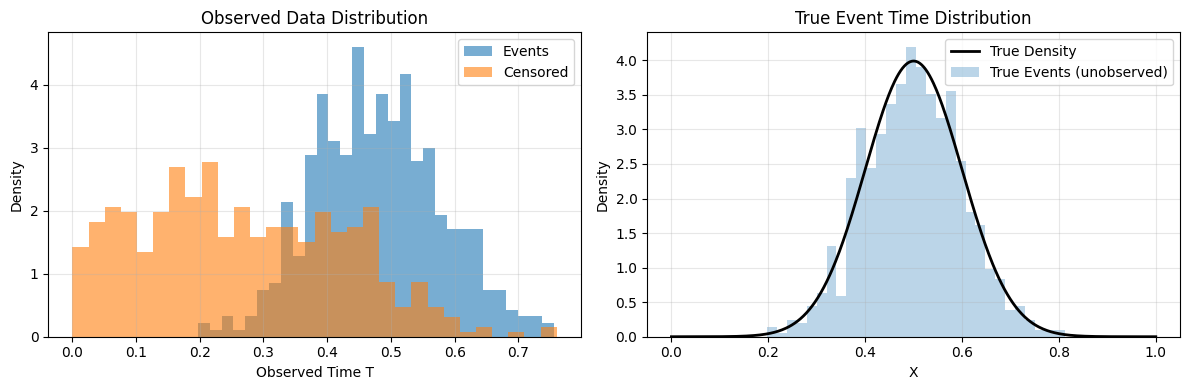

In [3]:
# Visualize data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Observed data histogram
axes[0].hist(data.loc[data['Delta'] == 1, 'T'], bins=30, alpha=0.6, label='Events', density=True)
axes[0].hist(data.loc[data['Delta'] == 0, 'T'], bins=30, alpha=0.6, label='Censored', density=True)
axes[0].set_xlabel('Observed Time T')
axes[0].set_ylabel('Density')
axes[0].set_title('Observed Data Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

# True density
grid = np.linspace(0, 1, 500)
true_density = truncnorm.pdf(grid, a, b, loc=mean, scale=std)
axes[1].plot(grid, true_density, 'k-', linewidth=2, label='True Density')
axes[1].hist(X_true, bins=30, alpha=0.3, density=True, label='True Events (unobserved)')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Density')
axes[1].set_title('True Event Time Distribution')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 2. Kaplan-Meier Censoring Survival

Estimate the **censoring survival function** `S_c(t) = P(C > t)` using Kaplan-Meier.


KM estimated at 1000 unique time points
S_c(0.0) = 1.0000
S_c(0.5) = 0.4897
S_c(1.0) = 0.0000


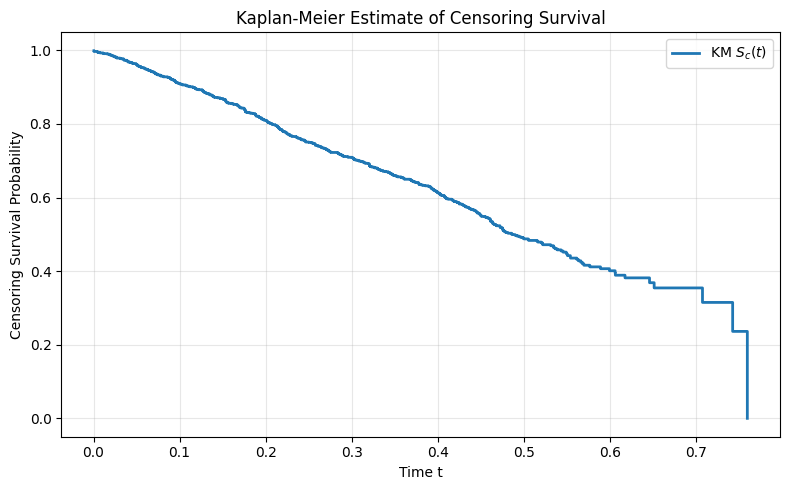

In [4]:
# Fit Kaplan-Meier for censoring survival
km = KaplanMeier()
km.fit(data, time_col="T", delta_col="Delta")

# Get step function for plotting
km_times, km_surv = km.stepwise_survival_()

print(f"KM estimated at {len(km_times)} unique time points")
print(f"S_c(0.0) = {km.predict(0.0):.4f}")
print(f"S_c(0.5) = {km.predict(0.5):.4f}")
print(f"S_c(1.0) = {km.predict(1.0):.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.step(km_times, km_surv, where='post', linewidth=2, label='KM $S_c(t)$')
plt.xlabel('Time t')
plt.ylabel('Censoring Survival Probability')
plt.title('Kaplan-Meier Estimate of Censoring Survival')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
# Compute IPCW weights
T_vals = np.asarray(data["T"].values, dtype=float)
Delta_vals = np.asarray(data["Delta"].values, dtype=int)

def S_c_predict(t):
    """Predict censoring survival - returns np.ndarray."""
    return np.atleast_1d(km.predict(t))

ipcw_weights = compute_ipcw_weights(T=T_vals, Delta=Delta_vals, S_c_predict=S_c_predict)

print(f"IPCW weights: min={ipcw_weights.min():.4f}, max={ipcw_weights.max():.4f}, mean={ipcw_weights.mean():.4f}")
print(f"Non-zero weights (events): {(ipcw_weights > 0).sum()}")


IPCW weights: min=0.0000, max=4.2326, mean=0.9958
Non-zero weights (events): 502


## 3. IPCW Baseline (Initial Estimate)

Fit a **weighted HAL density estimator** using only uncensored observations with IPCW weights.


In [6]:
# Fit IPCW-weighted HAL estimator
uncensored_mask = Delta_vals == 1
ipcw_data = pd.DataFrame({"W1": T_vals[uncensored_mask]})
ipcw_weights_unc = ipcw_weights[uncensored_mask]

ipcw_estimator = RightCensoredIPCWEstimator(
    norm_constraint=80,
    basis_order=1,
    solver="ECOS",
)
ipcw_estimator.fit(ipcw_data, sample_weights=ipcw_weights_unc)

# Results
ipcw_results = ipcw_estimator.get_results()
print(f"IPCW-HAL knots selected: {len(ipcw_results['grid_points_hal_selected'])}")

# Evaluate
eval_grid = np.linspace(0, 1, 500)
ipcw_density = ipcw_estimator.get_density_at_points(eval_grid)
ipcw_ll = incomplete_loglik(ipcw_estimator, data, time_col="T", delta_col="Delta")
ipcw_kl = kl_divergence(
    true_pdf_fn=lambda x: truncnorm.pdf(x, a, b, loc=mean, scale=std),
    grid=eval_grid,
    est_density=ipcw_density,
)

print(f"Log-likelihood: {ipcw_ll:.4f}")
print(f"KL divergence: {ipcw_ll:.4f}")


IPCW-HAL knots selected: 57
Log-likelihood: 340.4018
KL divergence: 340.4018


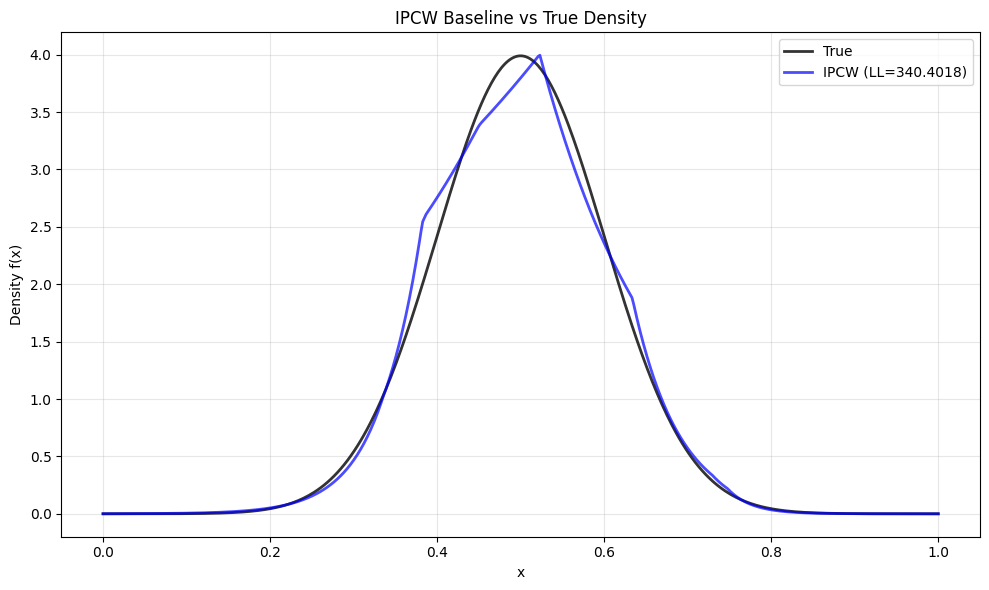

In [7]:
# Plot IPCW estimate
plt.figure(figsize=(10, 6))
plt.plot(grid, true_density, 'k-', linewidth=2, label='True', alpha=0.8)
plt.plot(eval_grid, ipcw_density, 'b-', linewidth=2, label=f'IPCW (LL={ipcw_ll:.4f})', alpha=0.7)
plt.xlabel('x')
plt.ylabel('Density f(x)')
plt.title('IPCW Baseline vs True Density')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. EM Stage Refinement (Standalone)

Use **`RightCensoredEMStage.run()`** to refine the IPCW estimate via EM iterations with multiple imputation.


In [8]:
# Configure and run EM Stage
em_stage = RightCensoredEMStage(
    m_imputations=30,       # Imputations per censored observation
    max_em_iter=20,         # Maximum EM iterations
    em_tol=1e-4,            # Convergence tolerance
    norm_constraint=80,      # L1 norm constraint for M-step
    n_grid_points=200,
    m_step_solver="ECOS",
    verbose=False,
    rng_seed=42,
)

# Run EM Stage with IPCW as initial working model
em_result = em_stage.run(
    initial_estimator=ipcw_estimator,
    data=data,
    S_c_predict=S_c_predict,
)

em_estimator = em_result.final_estimator
print(f"EM Stage Results:")
print(f"  Iterations: {em_result.em_iterations}")
print(f"  Converged: {em_result.em_converged}")


EM Stage Results:
  Iterations: 20
  Converged: False


In [9]:
# Evaluate EM Stage results
em_density = em_estimator.get_density_at_points(eval_grid)
em_ll = incomplete_loglik(em_estimator, data, time_col="T", delta_col="Delta")
em_kl = kl_divergence(
    true_pdf_fn=lambda x: truncnorm.pdf(x, a, b, loc=mean, scale=std),
    grid=eval_grid,
    est_density=em_density,
)

print(f"EM Stage: LL={em_ll:.4f}, LL={em_ll:.4f}")
print(f"\nImprovement over IPCW:")
print(f"  LL change: {em_ll - ipcw_ll:+.4f}")
print(f"  KL change: {em_kl - ipcw_kl:+.4f} (negative = better)")


EM Stage: LL=341.2258, LL=341.2258

Improvement over IPCW:
  LL change: +0.8240
  KL change: +0.0010 (negative = better)


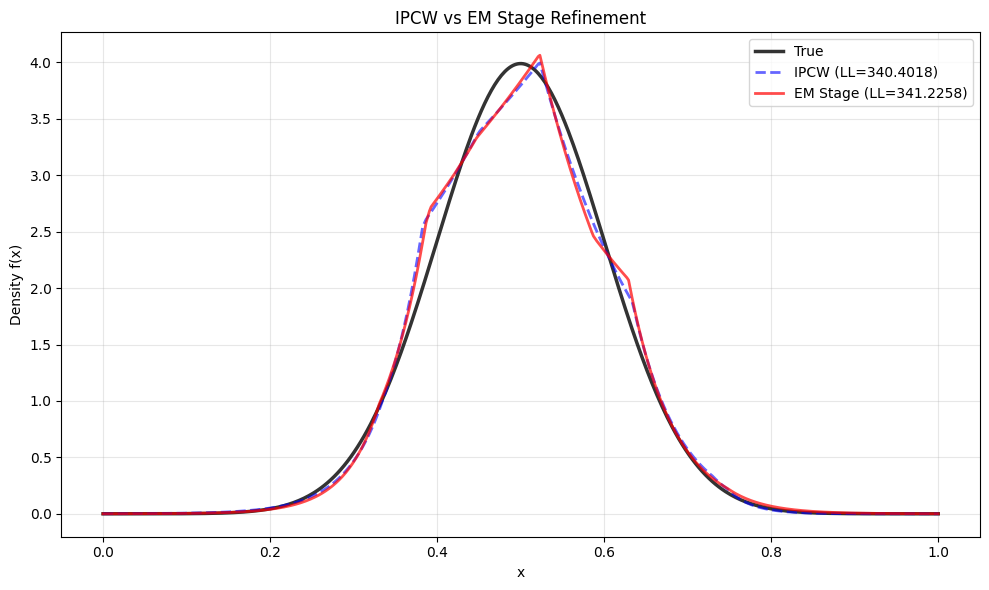

In [10]:
# Plot: IPCW vs EM Stage vs True
plt.figure(figsize=(10, 6))
plt.plot(grid, true_density, 'k-', linewidth=2.5, label='True', alpha=0.8)
plt.plot(eval_grid, ipcw_density, 'b--', linewidth=2, label=f'IPCW (LL={ipcw_ll:.4f})', alpha=0.6)
plt.plot(eval_grid, em_density, 'r-', linewidth=2, label=f'EM Stage (LL={em_ll:.4f})', alpha=0.7)
plt.xlabel('x')
plt.ylabel('Density f(x)')
plt.title('IPCW vs EM Stage Refinement')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 5. EM Estimator (Bundled IPCW + EM)

`RightCensoredEMEstimator` bundles IPCW initialization and EM refinement into a single convenient estimator.


In [11]:
# Fit bundled EM Estimator
bundled_estimator = RightCensoredEMEstimator(
    norm_constraint=80,
    m_step_norm_constraint=80,
    m_imputations=30,
    max_em_iter=30,
    em_tol=1e-4,
    basis_order=1,
    init_solver="ECOS",
    m_step_solver="ECOS",
    rng_seed=42,
    verbose=False,
)
bundled_estimator.fit(data)

# Evaluate
bundled_results = bundled_estimator.get_results()
bundled_density = bundled_estimator.get_density_at_points(eval_grid)
bundled_ll = incomplete_loglik(bundled_estimator, data, time_col="T", delta_col="Delta")
bundled_kl = kl_divergence(
    true_pdf_fn=lambda x: truncnorm.pdf(x, a, b, loc=mean, scale=std),
    grid=eval_grid,
    est_density=bundled_density,
)

print(f"EM Estimator (Bundled):")
print(f"  EM iterations: {bundled_results['em_iterations']}")
print(f"  LL={bundled_ll:.4f}, LL={bundled_ll:.4f}")


EM Estimator (Bundled):
  EM iterations: 30
  LL=341.1887, LL=341.1887


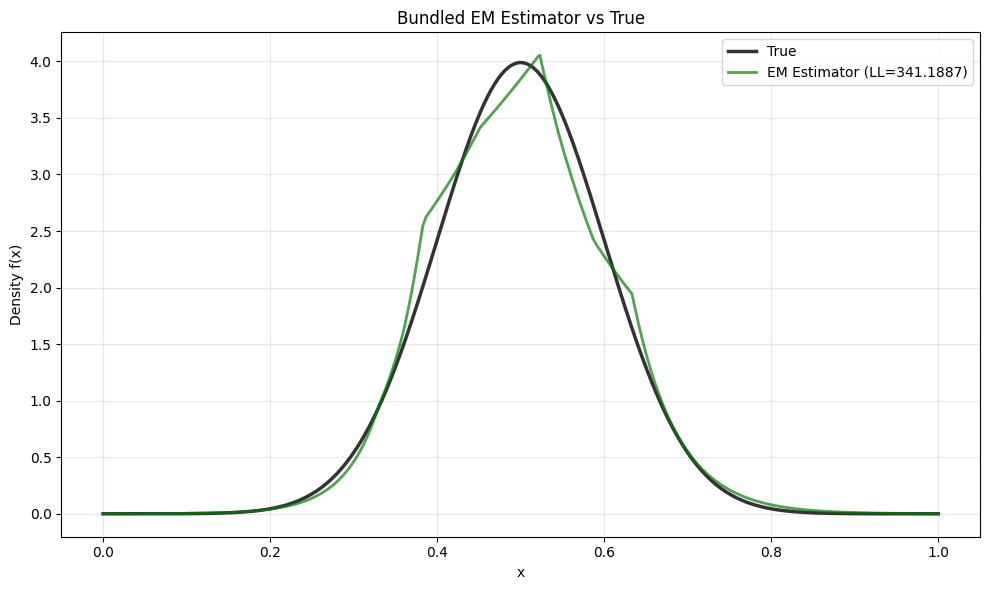

In [12]:
# Plot: Bundled EM Estimator vs True
plt.figure(figsize=(10, 6))
plt.plot(eval_grid, true_density, 'k-', linewidth=2.5, label='True', alpha=0.8)
plt.plot(eval_grid, bundled_density, 'g-', linewidth=2, label=f'EM Estimator (LL={bundled_ll:.4f})', alpha=0.7)
plt.xlabel('x')
plt.ylabel('Density f(x)')
plt.title('Bundled EM Estimator vs True')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Hyperparameter Tuning

Three tuning approaches with different speed/flexibility tradeoffs:

| Approach | What It Tunes | When to Use |
|----------|---------------|-------------|
| **IPCW Tuner** | `basis_order`, `norm_constraint` | Fast baseline, no EM |
| **Two-Stage Tuner** | Stage 1: IPCW → Stage 2: EM | Automated end-to-end |
| **EM Tuner** | `m_step_norm_multiplier` only | Pre-fitted IPCW model |


### 6a. IPCW Tuner (Fast Baseline)

Tune only `basis_order` and `norm_constraint` using IPCW — no EM iterations.


In [13]:
# IPCW-only tuner (no EM)
ipcw_tuner = RightCensoredOptunaHyperparameterTuner(
    estimator_name="RightCensoredIPCWEstimator",
    data=data,
    cv_folds=3,
    random_state=42,
    n_grid_points=200,
    param_overrides={
        "norm_constraint": {"low": 10.0, "high": 500.0, "log": True},
        "basis_order": [0, 1, 2],
    },
    silent=False,
)

start_time = time.time()
ipcw_result = ipcw_tuner.optimize(n_trials=50)
print(f"\nOptimization time: {time.time() - start_time:.4f}s")
print(f"Best params: {ipcw_result['best_params']}")
print(f"Best LL: {ipcw_result['best_metric_value']:.4f}")


Optuna CV: 100%|██████████| 50/50 [00:39<00:00,  1.26trial/s, LL=111.18, best=111.63, order=2]


Optimization time: 39.5418s
Best params: {'basis_order': 2, 'norm_constraint': 69.10244477634623}
Best LL: 111.6270


In [14]:
# Fit best IPCW model and evaluate
best_ipcw = ipcw_tuner.fit_best_model()
ipcw_tuned_density = best_ipcw.get_density_at_points(eval_grid)
ipcw_tuned_ll = incomplete_loglik(best_ipcw, data, time_col="T", delta_col="Delta")
ipcw_tuned_kl = kl_divergence(
    true_pdf_fn=lambda x: truncnorm.pdf(x, a, b, loc=mean, scale=std),
    grid=eval_grid,
    est_density=ipcw_tuned_density,
)
print(f"CV-Tuned IPCW: LL={ipcw_tuned_ll:.4f}, LL={ipcw_tuned_ll:.4f}")


CV-Tuned IPCW: LL=336.6178, LL=336.6178


### 6b. EM Tuner (After IPCW Tuning)

Tune EM refinement with the tuned IPCW as initial model.


In [15]:
# EM Tuner with pre-tuned IPCW model
em_tuner = RightCensoredEMStageTuner(
    data=data,
    initial_estimator=best_ipcw,  # Use CV-tuned IPCW from above
    S_c_predict=S_c_predict,
    cv_folds=3,
    param_ranges={"m_step_norm_multiplier": {"low": 0.5, "high": 1.0, "log": True}},
    em_defaults={"m_imputations": 20, "max_em_iter": 10},
    silent=True,
)

start_time = time.time()
em_best_params = em_tuner.optimize(n_trials=20)
print(f"\nEM Tuner time: {time.time() - start_time:.4f}s")
print(f"Best EM params: {em_best_params}")



EM Tuner time: 161.9094s
Best EM params: {'m_step_norm_multiplier': 0.9948526455898474}


In [16]:
# Fit best EM Tuner model and evaluate
em_tuner_result = em_tuner.fit_best_model()
em_tuner_estimator = em_tuner_result.final_estimator
em_tuner_density = em_tuner_estimator.get_density_at_points(eval_grid)
em_tuner_ll = incomplete_loglik(em_tuner_estimator, data, time_col="T", delta_col="Delta")
em_tuner_kl = kl_divergence(
    true_pdf_fn=lambda x: truncnorm.pdf(x, a, b, loc=mean, scale=std),
    grid=eval_grid,
    est_density=em_tuner_density,
)
print(f"EM Tuner: LL={em_tuner_ll:.4f}, LL={em_tuner_ll:.4f}")
print(f"\nImprovement over CV-IPCW:")
print(f"  LL change: {em_tuner_ll - ipcw_tuned_ll:+.4f}")
print(f"  KL change: {em_tuner_kl - ipcw_tuned_kl:+.4f}")


EM Tuner: LL=336.7149, LL=336.7149

Improvement over CV-IPCW:
  LL change: +0.0971
  KL change: +0.0005


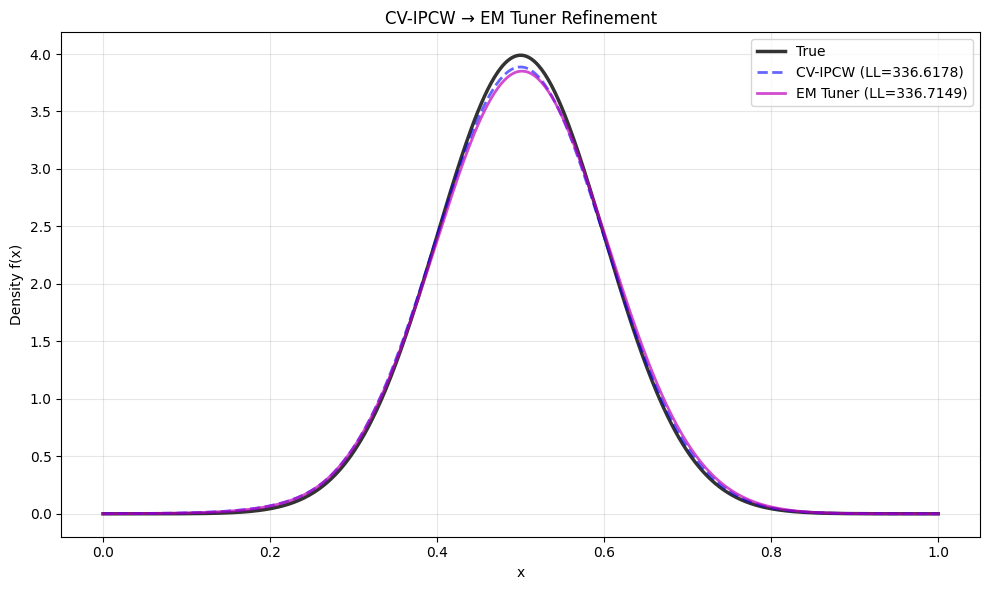

In [17]:
# Plot: CV-IPCW vs EM Tuner refinement
plt.figure(figsize=(10, 6))
plt.plot(grid, true_density, 'k-', linewidth=2.5, label='True', alpha=0.8)
plt.plot(eval_grid, ipcw_tuned_density, 'b--', linewidth=2, label=f'CV-IPCW (LL={ipcw_tuned_ll:.4f})', alpha=0.6)
plt.plot(eval_grid, em_tuner_density, 'm-', linewidth=2, label=f'EM Tuner (LL={em_tuner_ll:.4f})', alpha=0.7)
plt.xlabel('x')
plt.ylabel('Density f(x)')
plt.title('CV-IPCW → EM Tuner Refinement')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 6c. Two-Stage Tuner (Automated End-to-End)

Automates the two-stage workflow: Stage 1 tunes IPCW, Stage 2 tunes EM.


In [18]:
# Two-Stage Tuner (automated IPCW + EM tuning)
two_stage_tuner = RightCensoredTwoStageTuner(
    data=data,
    cv_folds=3,
    random_state=42,
    stage1_param_ranges={
        "norm_constraint": {"low": 10.0, "high": 500.0, "log": True},
        "basis_order": [0, 1, 2],
    },
    stage2_param_ranges={
        "m_step_norm_multiplier": {"low": 0.5, "high": 1.0, "log": True},
    },
    em_defaults={"m_imputations": 20, "max_em_iter": 10},
    silent=False,
)

start_time = time.time()
two_stage_best = two_stage_tuner.optimize(n_trials_stage1=30, n_trials_stage2=15)
print(f"\nTwo-Stage Tuner time: {time.time() - start_time:.4f}s")
print(f"Best params: {two_stage_best}")


Stage 2 (EM): 100%|██████████| 15/15 [02:17<00:00,  9.15s/trial, LL=111.69, best=111.71, mult=0.98]


Two-Stage Tuner time: 164.6375s
Best params: {'norm_constraint': 66.3896109755839, 'basis_order': 2, 'm_step_norm_multiplier': 0.994508738817709}


In [19]:
# Fit best Two-Stage model and evaluate
two_stage_result = two_stage_tuner.fit_best_model()
two_stage_estimator = two_stage_result.final_estimator
two_stage_density = two_stage_estimator.get_density_at_points(eval_grid)
two_stage_ll = incomplete_loglik(two_stage_estimator, data, time_col="T", delta_col="Delta")
two_stage_kl = kl_divergence(
    true_pdf_fn=lambda x: truncnorm.pdf(x, a, b, loc=mean, scale=std),
    grid=eval_grid,
    est_density=two_stage_density,
)
print(f"Two-Stage Tuner: LL={two_stage_ll:.4f}, LL={two_stage_ll:.4f}")


Two-Stage Tuner: LL=335.9653, LL=335.9653


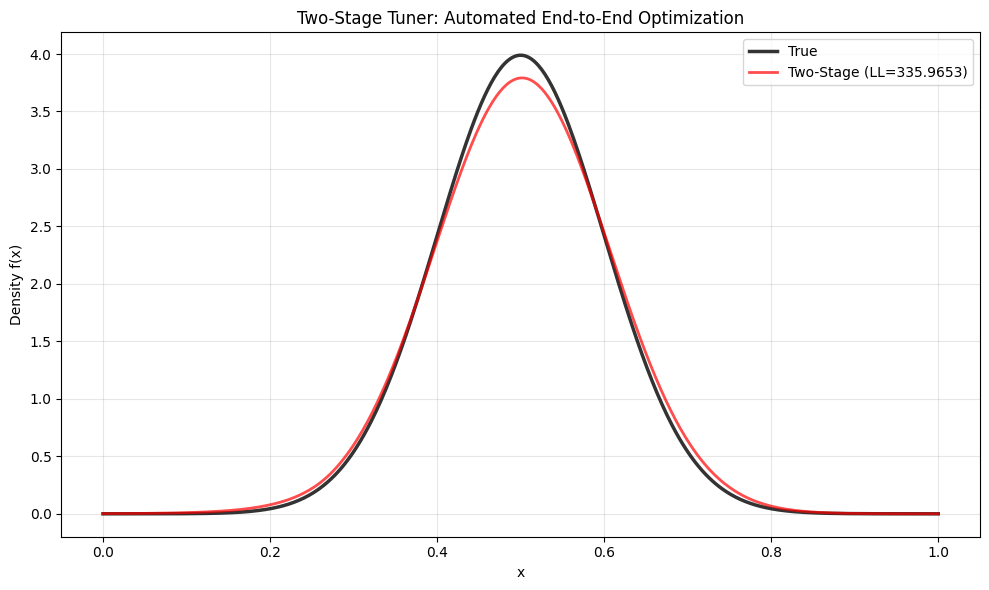

In [20]:
# Plot: Two-Stage Tuner result
plt.figure(figsize=(10, 6))
plt.plot(grid, true_density, 'k-', linewidth=2.5, label='True', alpha=0.8)
plt.plot(eval_grid, two_stage_density, 'r-', linewidth=2, label=f'Two-Stage (LL={two_stage_ll:.4f})', alpha=0.7)
plt.xlabel('x')
plt.ylabel('Density f(x)')
plt.title('Two-Stage Tuner: Automated End-to-End Optimization')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Summary Comparison


In [21]:
# Summary table
print("=" * 70)
print("SUMMARY: All Methods Comparison")
print("=" * 70)

results_summary = pd.DataFrame({
    "Method": [
        "1. IPCW (baseline)",
        "2. EM Stage (manual)",
        "3. EM Estimator (bundled)",
        "4. CV-IPCW (tuned)",
        "5. EM Tuner (IPCW→EM)",
        "6. Two-Stage (automated)",
    ],
    "Log-Likelihood": [ipcw_ll, em_ll, bundled_ll, ipcw_tuned_ll, em_tuner_ll, two_stage_ll],
    "KL Divergence": [ipcw_kl, em_kl, bundled_kl, ipcw_tuned_kl, em_tuner_kl, two_stage_kl],
})
print(results_summary.to_string(index=False))
print("=" * 70)


SUMMARY: All Methods Comparison
                   Method  Log-Likelihood  KL Divergence
       1. IPCW (baseline)      340.401803       0.003643
     2. EM Stage (manual)      341.225806       0.004618
3. EM Estimator (bundled)      341.188718       0.005723
       4. CV-IPCW (tuned)      336.617797       0.001485
    5. EM Tuner (IPCW→EM)      336.714899       0.001969
 6. Two-Stage (automated)      335.965254       0.003613


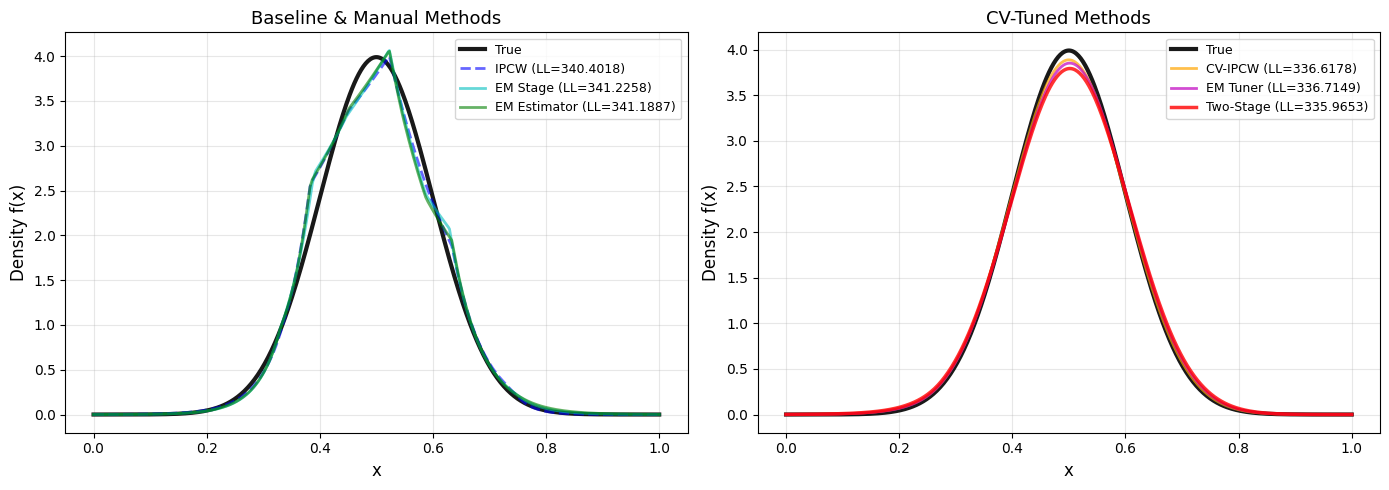

In [22]:
# Final comparison plot - All methods
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Baseline & Manual methods
axes[0].plot(grid, true_density, 'k-', linewidth=3, label='True', alpha=0.9)
axes[0].plot(eval_grid, ipcw_density, 'b--', linewidth=2, label=f'IPCW (LL={ipcw_ll:.4f})', alpha=0.6)
axes[0].plot(eval_grid, em_density, 'c-', linewidth=2, label=f'EM Stage (LL={em_ll:.4f})', alpha=0.6)
axes[0].plot(eval_grid, bundled_density, 'g-', linewidth=2, label=f'EM Estimator (LL={bundled_ll:.4f})', alpha=0.6)
axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('Density f(x)', fontsize=12)
axes[0].set_title('Baseline & Manual Methods', fontsize=13)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Right plot: Tuned methods
axes[1].plot(grid, true_density, 'k-', linewidth=3, label='True', alpha=0.9)
axes[1].plot(eval_grid, ipcw_tuned_density, 'orange', linewidth=2, label=f'CV-IPCW (LL={ipcw_tuned_ll:.4f})', alpha=0.7)
axes[1].plot(eval_grid, em_tuner_density, 'm-', linewidth=2, label=f'EM Tuner (LL={em_tuner_ll:.4f})', alpha=0.7)
axes[1].plot(eval_grid, two_stage_density, 'r-', linewidth=2.5, label=f'Two-Stage (LL={two_stage_ll:.4f})', alpha=0.8)
axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('Density f(x)', fontsize=12)
axes[1].set_title('CV-Tuned Methods', fontsize=13)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Key Takeaways

### Estimators

| Short Name | Class | Use When |
|------------|-------|----------|
| IPCW | `RightCensoredIPCWEstimator` | Fast baseline, no EM |
| EM Stage | `RightCensoredEMStage` | Full control over initial model |
| EM Estimator | `RightCensoredEMEstimator` | Convenience (single call) |

### Tuners

| Short Name | Class | Best For |
|------------|-------|----------|
| IPCW Tuner | `RightCensoredOptunaHyperparameterTuner` | Fast IPCW-only tuning |
| EM Tuner | `RightCensoredEMStageTuner` | When IPCW is already tuned |
| Two-Stage | `RightCensoredTwoStageTuner` | Automated end-to-end |

### Recommended Workflow

**Option A: Manual Two-Stage (Maximum Control)**
1. Tune IPCW with `RightCensoredOptunaHyperparameterTuner`
2. Fit best IPCW model
3. Tune EM with `RightCensoredEMStageTuner` using fitted IPCW

**Option B: Automated Two-Stage (Convenience)**
1. Use `RightCensoredTwoStageTuner` for full automation
2. Handles both stages internally
